In [21]:
import sys
sys.path.append("..")

import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)
from xgboost import XGBClassifier

Path("../outputs/figures").mkdir(parents=True, exist_ok=True)
Path("../outputs/models").mkdir(parents=True, exist_ok=True)

# 03_1 — Baseline Models: Random Forest & XGBoost

Trains and compares two baseline models on the leakage-free train/test split
prepared in `02_features.ipynb`.

**Models:**
- Random Forest — tree-based ensemble, interpretable, robust
- XGBoost — gradient boosting, typically stronger on tabular data

**Evaluation priority:** minimise False Negatives (missed anomalies).
A missed anomaly is more costly than a false alarm in oil well monitoring.

**Input:**  `outputs/features_train.parquet`, `outputs/features_test.parquet`
**Output:** `outputs/models/random_forest_baseline.pkl`, `outputs/models/xgboost_baseline.pkl`

In [22]:
TRAIN_PATH = "../outputs/features_train.parquet"
TEST_PATH  = "../outputs/features_test.parquet"

df_feat_train = pd.read_parquet(TRAIN_PATH)
df_feat_test  = pd.read_parquet(TEST_PATH)

# P-PDG dropped — dead sensor (all zeros in this dataset version)
DEAD_FEATURES = ["P-PDG_mean", "P-PDG_std", "P-PDG_min",
                 "P-PDG_max", "P-PDG_range", "P-PDG_trend"]

feature_cols = [c for c in df_feat_train.columns
                if c not in ("label", "event_type", "source")
                and c not in DEAD_FEATURES]

X_train = df_feat_train[feature_cols].values
y_train = df_feat_train["label"].values
X_test  = df_feat_test[feature_cols].values
y_test  = df_feat_test["label"].values

print(f"Features:      {len(feature_cols)}")
print(f"Train windows: {len(X_train):,}  |  anomaly rate: {y_train.mean()*100:.1f}%")
print(f"Test windows:  {len(X_test):,}   |  anomaly rate: {y_test.mean()*100:.1f}%")

Features:      24
Train windows: 80,938  |  anomaly rate: 70.2%
Test windows:  40,758   |  anomaly rate: 84.0%


## 1. Random Forest Baseline

In [13]:
print("Training Random Forest baseline...")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

with open("../outputs/models/random_forest_baseline.pkl", "wb") as f:
    pickle.dump(rf, f)

print("Saved: random_forest_baseline.pkl")

Training Random Forest baseline...
Saved: random_forest_baseline.pkl


In [14]:
y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
roc_rf     = roc_auc_score(y_test, y_proba_rf)
cm_rf      = confusion_matrix(y_test, y_pred_rf)

print("=== Random Forest Baseline ===")
print(classification_report(y_test, y_pred_rf,
                             target_names=["Normal", "Anomaly"]))
print(f"ROC-AUC : {roc_rf:.4f}")
print(f"FN      : {cm_rf[1,0]}  (missed anomalies)")
print(f"FP      : {cm_rf[0,1]}  (false alarms)")

# Overfitting check
roc_train_rf = roc_auc_score(y_train, rf.predict_proba(X_train)[:, 1])
print(f"\nTrain ROC-AUC: {roc_train_rf:.4f}  |  Test: {roc_rf:.4f}  |  Gap: {roc_train_rf - roc_rf:+.4f}")

=== Random Forest Baseline ===
              precision    recall  f1-score   support

      Normal       0.89      0.30      0.45      6515
     Anomaly       0.88      0.99      0.93     34243

    accuracy                           0.88     40758
   macro avg       0.89      0.65      0.69     40758
weighted avg       0.88      0.88      0.86     40758

ROC-AUC : 0.9154
FN      : 234  (missed anomalies)
FP      : 4536  (false alarms)

Train ROC-AUC: 0.9999  |  Test: 0.9154  |  Gap: +0.0845


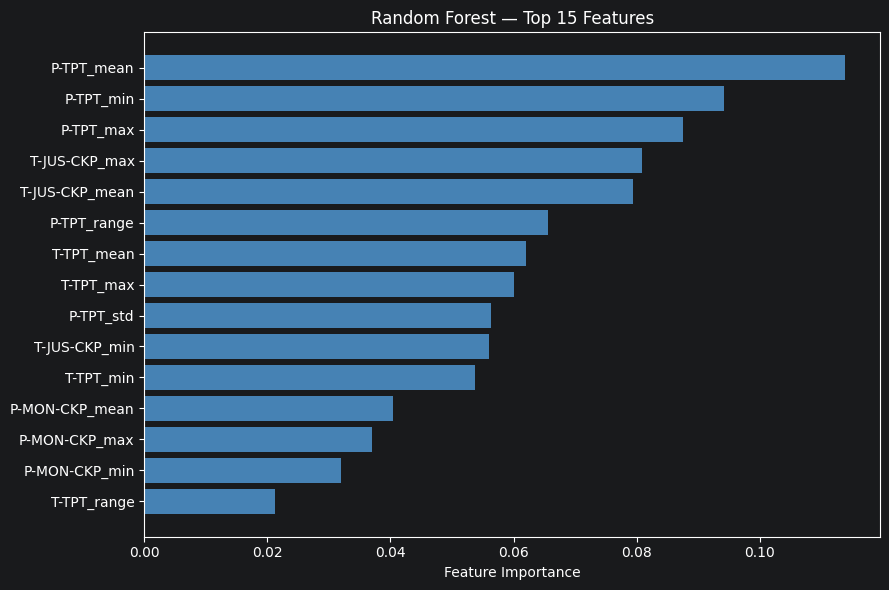

In [15]:
importances = pd.Series(rf.feature_importances_, index=feature_cols)
top15 = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(9, 6))
plt.barh(top15.index, top15.values, color="steelblue")
plt.xlabel("Feature Importance")
plt.title("Random Forest — Top 15 Features")
plt.tight_layout()
plt.savefig("../outputs/figures/rf_feature_importance.png", dpi=150)
plt.show()

## 2. XGBoost Baseline

In [16]:
print("Training XGBoost baseline...")

# scale_pos_weight compensates for class imbalance
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=pos_weight,
    random_state=42,
    eval_metric="logloss",
    verbosity=0,
)
xgb.fit(X_train, y_train)

with open("../outputs/models/xgboost_baseline.pkl", "wb") as f:
    pickle.dump(xgb, f)

print("Saved: xgboost_baseline.pkl")

Training XGBoost baseline...
Saved: xgboost_baseline.pkl


In [17]:
y_pred_xgb  = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
roc_xgb     = roc_auc_score(y_test, y_proba_xgb)
cm_xgb      = confusion_matrix(y_test, y_pred_xgb)

print("=== XGBoost Baseline ===")
print(classification_report(y_test, y_pred_xgb,
                             target_names=["Normal", "Anomaly"]))
print(f"ROC-AUC : {roc_xgb:.4f}")
print(f"FN      : {cm_xgb[1,0]}  (missed anomalies)")
print(f"FP      : {cm_xgb[0,1]}  (false alarms)")

# Overfitting check
roc_train_xgb = roc_auc_score(y_train, xgb.predict_proba(X_train)[:, 1])
print(f"\nTrain ROC-AUC: {roc_train_xgb:.4f}  |  Test: {roc_xgb:.4f}  |  Gap: {roc_train_xgb - roc_xgb:+.4f}")

=== XGBoost Baseline ===
              precision    recall  f1-score   support

      Normal       0.86      0.32      0.47      6515
     Anomaly       0.88      0.99      0.93     34243

    accuracy                           0.88     40758
   macro avg       0.87      0.66      0.70     40758
weighted avg       0.88      0.88      0.86     40758

ROC-AUC : 0.8066
FN      : 350  (missed anomalies)
FP      : 4409  (false alarms)

Train ROC-AUC: 0.9999  |  Test: 0.8066  |  Gap: +0.1933


## 3. Comparison

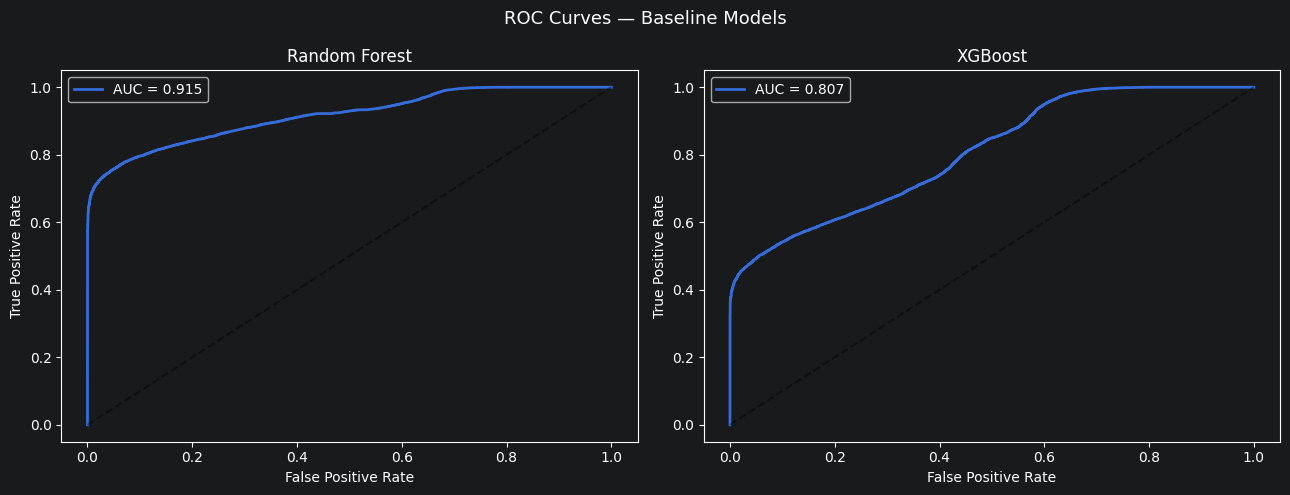

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, y_proba, roc) in zip(axes, [
    ("Random Forest", y_proba_rf,  roc_rf),
    ("XGBoost",       y_proba_xgb, roc_xgb),
]):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc:.3f}")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.set_title(name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()

plt.suptitle("ROC Curves — Baseline Models", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/figures/baseline_roc_curves.png", dpi=150)
plt.show()

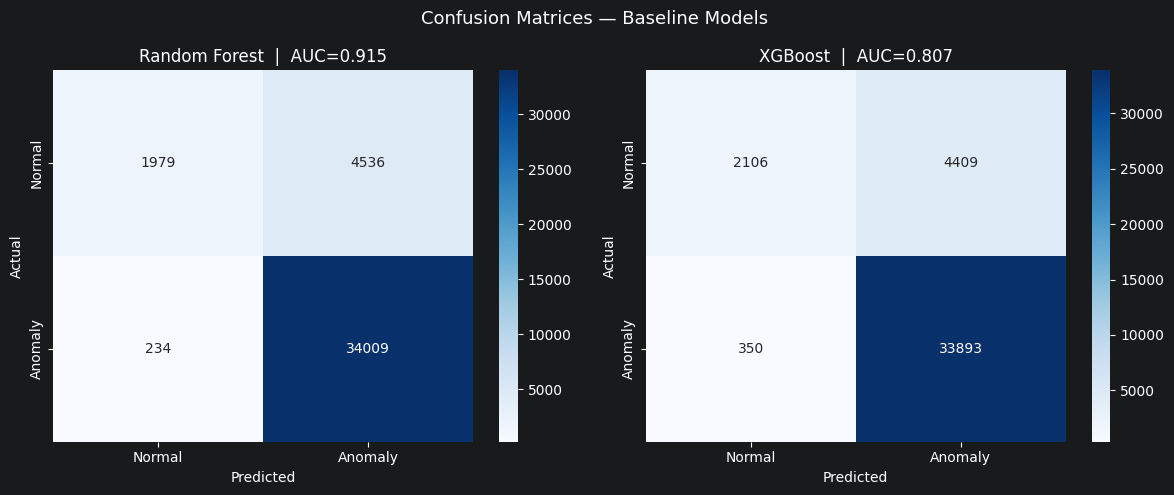

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, y_pred, roc) in zip(axes, [
    ("Random Forest", y_pred_rf,  roc_rf),
    ("XGBoost",       y_pred_xgb, roc_xgb),
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal", "Anomaly"],
                yticklabels=["Normal", "Anomaly"])
    ax.set_title(f"{name}  |  AUC={roc:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Baseline Models", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/figures/baseline_confusion_matrices.png", dpi=150)
plt.show()

In [20]:
print(f"{'Model':<22} {'ROC-AUC':>8} {'F1-macro':>9} {'FN':>6} {'FP':>6}")
print("─" * 55)

for name, y_pred, y_proba in [
    ("Random Forest",  y_pred_rf,  y_proba_rf),
    ("XGBoost",        y_pred_xgb, y_proba_xgb),
]:
    roc = roc_auc_score(y_test, y_proba)
    f1  = f1_score(y_test, y_pred, average="macro")
    cm  = confusion_matrix(y_test, y_pred)
    print(f"{name:<22} {roc:>8.4f} {f1:>9.4f} {cm[1,0]:>6} {cm[0,1]:>6}")

print("\nNext: 03_2_modeling_lstm.ipynb  |  03_3_modeling_exp.ipynb")

Model                   ROC-AUC  F1-macro     FN     FP
───────────────────────────────────────────────────────
Random Forest            0.9154    0.6940    234   4536
XGBoost                  0.8066    0.7020    350   4409

Next: 03_2_modeling_lstm.ipynb  |  03_3_modeling_exp.ipynb
